# 04 — Grad-CAM Explainability

**Kaggle:** same inputs as notebook 03 (dataset + output of 02b); Accelerator = GPU; Internet = On.

Theory: [`docs/06_gradcam.md`](../docs/06_gradcam.md)

In [1]:
# --- environment setup: works on Kaggle, Colab and locally ---
import sys, os
REPO = "https://github.com/Mohd2Shaan/Deepfake-Detection-Project.git"
ON_KAGGLE = os.path.exists("/kaggle/input")
ON_COLAB = "google.colab" in sys.modules
if ON_KAGGLE or ON_COLAB:
    PROJECT = "/kaggle/working/project" if ON_KAGGLE else "/content/project"
    if os.path.exists(PROJECT):
        !git -C {PROJECT} pull -q
    else:
        !git clone -q {REPO} {PROJECT}
    %cd {PROJECT}
    EXTRA = "" if ON_KAGGLE else "kagglehub"
    !pip install -q grad-cam {EXTRA}
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working dir:", os.getcwd())

/kaggle/working/project
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 903.6 kB/s eta 0:00:00 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
working dir: /kaggle/working/project


In [2]:
# --- dataset: Kaggle -> attached input is found automatically; Colab/local -> downloaded once (~4 GB) ---
from src import config
if ON_KAGGLE:
    for ckpt in config.import_kaggle_checkpoints():      # notebooks 03/04: models from notebook 02's output
        print("trained model:", ckpt)
if not (config.DATA_DIR / "train").exists():
    if ON_KAGGLE:
        raise RuntimeError("Dataset not found - attach '140k Real and Fake Faces' with Add Input")
    !python scripts/download_dataset.py --move
print("data dir:", config.DATA_DIR)

trained model: /kaggle/working/project/checkpoints/resnet_best.pth
trained model: /kaggle/working/project/checkpoints/efficientnet_best.pth
data dir: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces/real_vs_fake/real-vs-fake


In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image
from src import config
from src.model import load_checkpoint, get_target_layer
from src.gradcam import GradCAMExplainer, manual_gradcam, save_heatmap_grid, pick_correct_examples

device = config.get_device()
model, ckpt = load_checkpoint(config.CHECKPOINT_DIR / 'efficientnet_best.pth', device)
name = ckpt['model_name']
explainer = GradCAMExplainer(model, name, device)

## 1. Correctly classified real and fake faces
The misclassified grid needs the error list from notebook 03 — it is recomputed here if missing.

In [4]:
if not list(config.MISCLASSIFIED_DIR.glob('*_most_confident_errors.csv')):
    !python -m src.evaluate --num-workers 4


===== efficientnet_b0  (/kaggle/working/project/checkpoints/efficientnet_best.pth) =====
              precision    recall  f1-score   support                           

        real     0.9988    0.9979    0.9983     10000
        fake     0.9979    0.9988    0.9984     10000

    accuracy                         0.9983     20000
   macro avg     0.9984    0.9984    0.9983     20000
weighted avg     0.9984    0.9983    0.9983     20000

misclassified: 33 / 20000

===== resnet18  (/kaggle/working/project/checkpoints/resnet_best.pth) =====
              precision    recall  f1-score   support                           

        real     0.9937    0.9857    0.9897     10000
        fake     0.9858    0.9938    0.9898     10000

    accuracy                         0.9898     20000
   macro avg     0.9898    0.9898    0.9897     20000
weighted avg     0.9898    0.9898    0.9897     20000

misclassified: 205 / 20000

===== comparison =====
                 accuracy  precision  recall    

saved /kaggle/working/project/outputs/heatmaps/efficientnet_b0_correct_real.png
saved /kaggle/working/project/outputs/heatmaps/efficientnet_b0_correct_fake.png
saved /kaggle/working/project/outputs/heatmaps/efficientnet_b0_misclassified.png


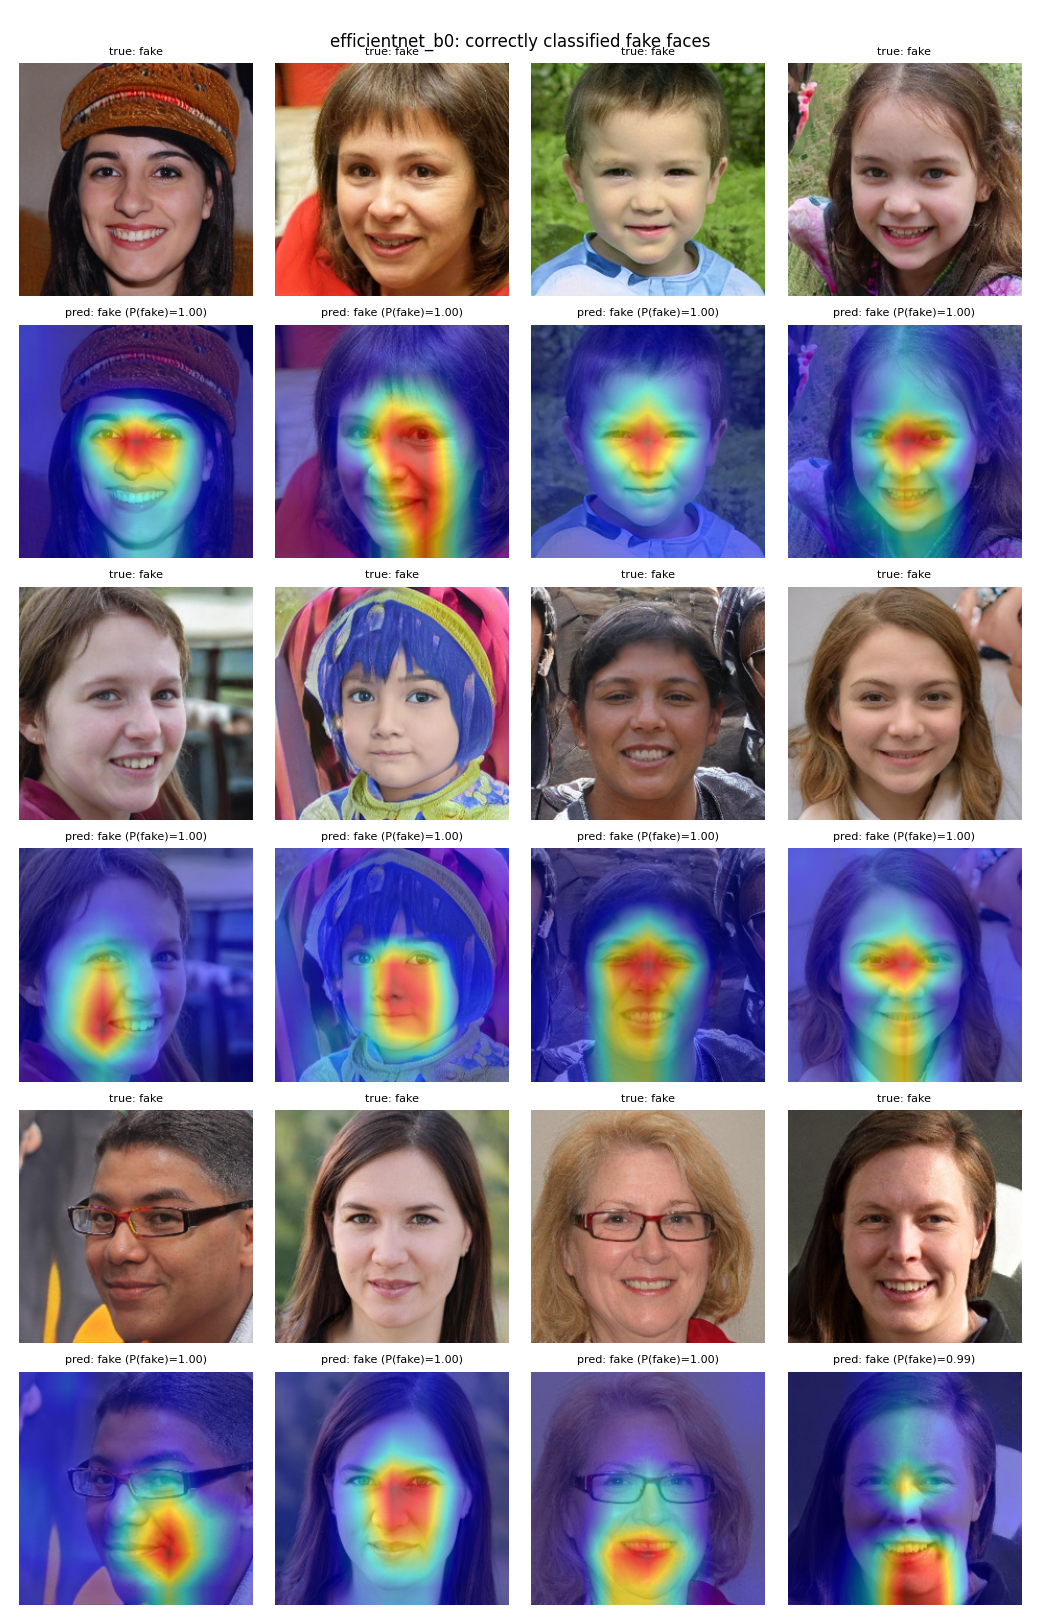

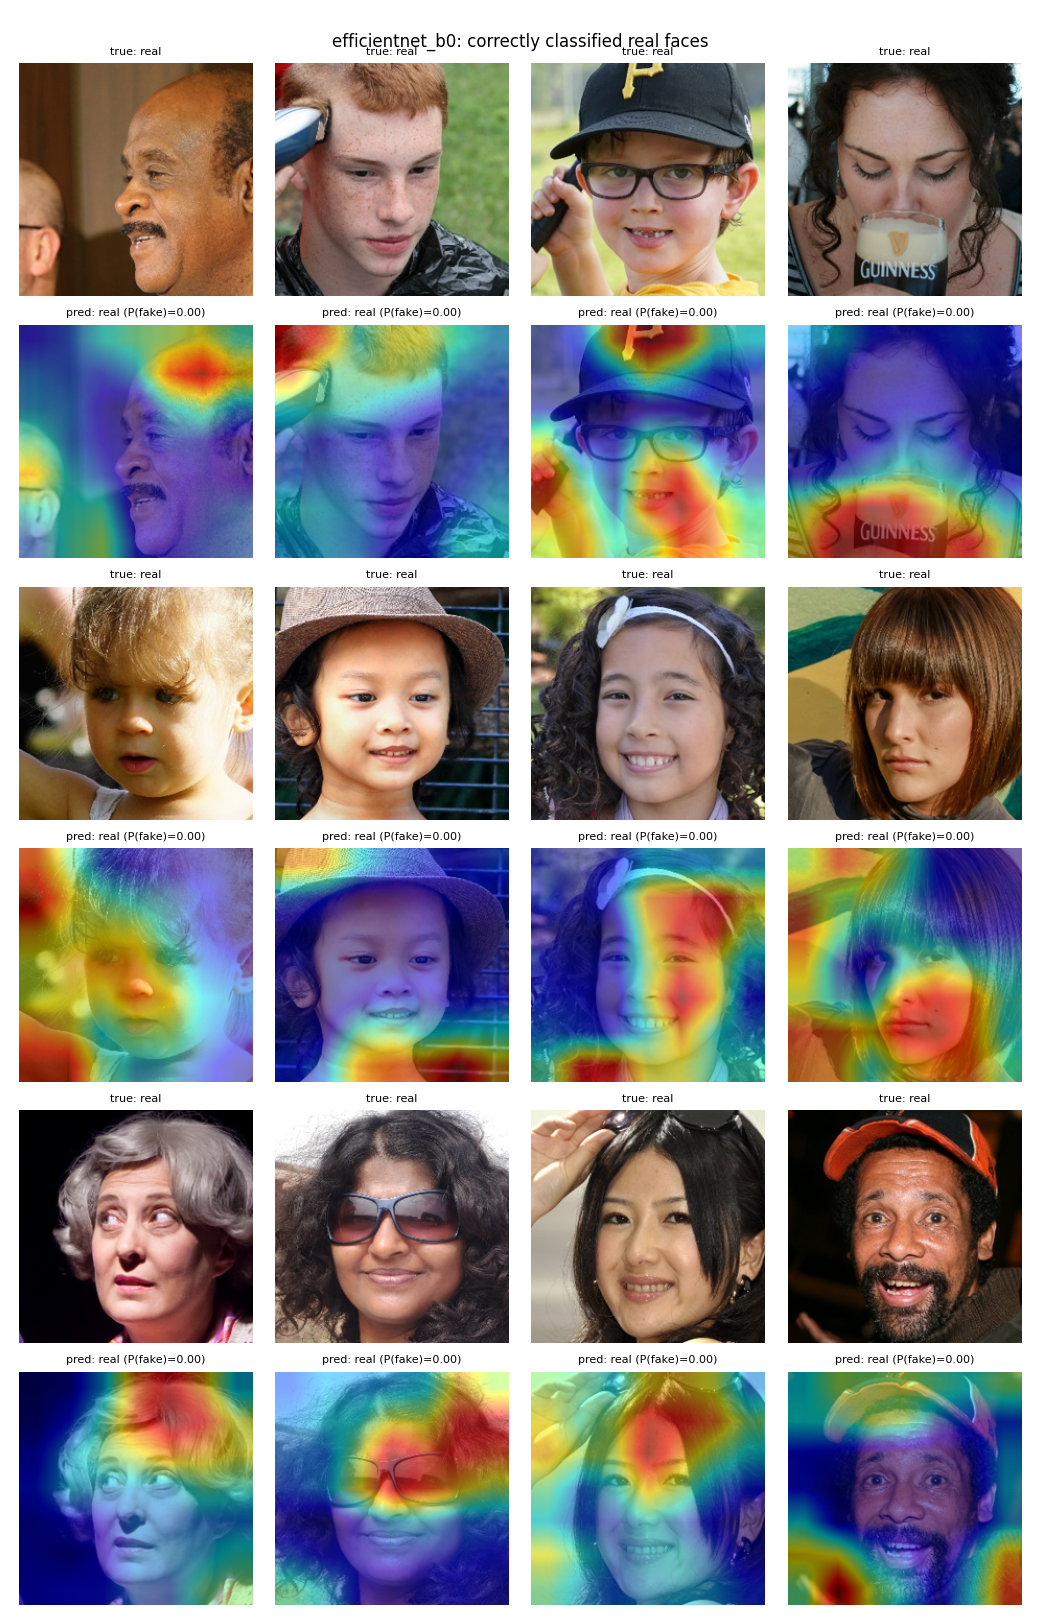

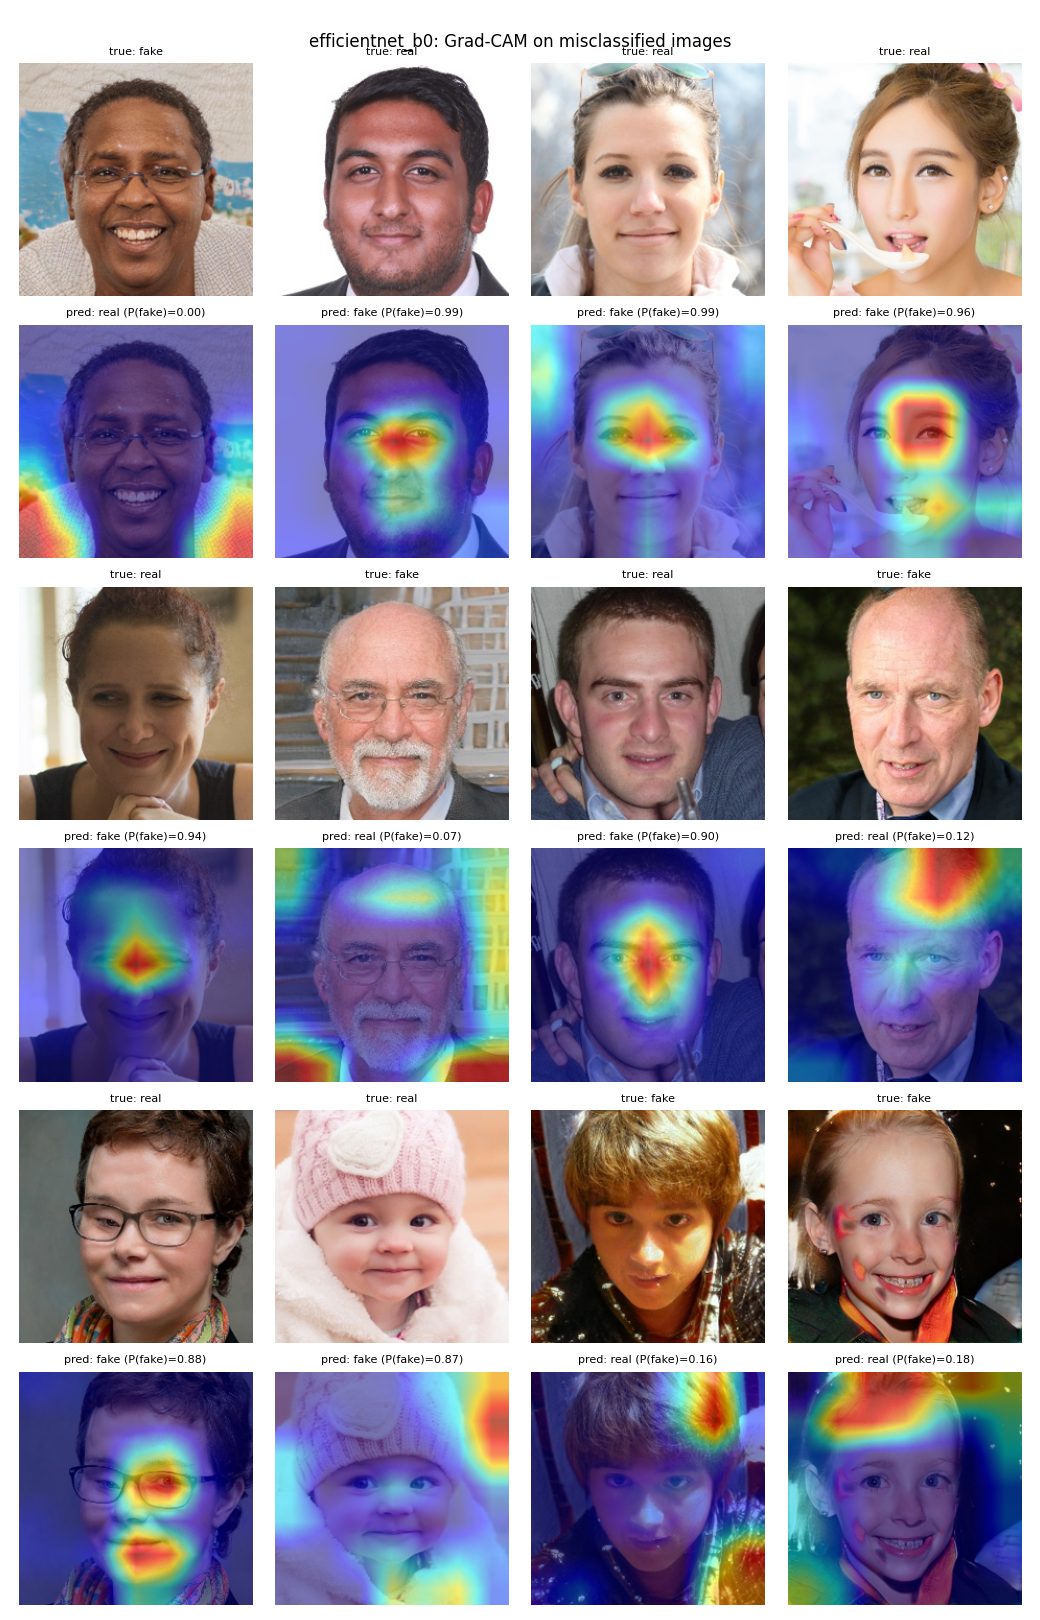

In [5]:
!python -m src.gradcam --checkpoint checkpoints/efficientnet_best.pth --n 12
from IPython.display import Image as Show, display
for p in sorted(config.HEATMAP_DIR.glob(f'{name}_*.png')):
    display(Show(str(p)))

## 2. Library Grad-CAM vs hand-written Grad-CAM
Both should produce (almost) the same map — shows we understand what the library computes.

correlation: 0.9999999999999234


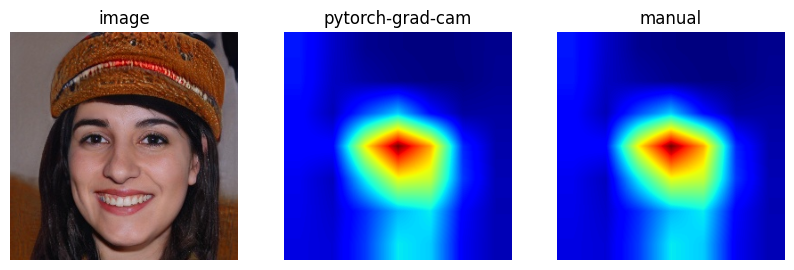

In [6]:
import numpy as np
path = pick_correct_examples(explainer, config.DATA_DIR, 1, 'fake')[0]
img = Image.open(path)
lib = explainer.explain(img, target_class=1)['cam']
x = explainer.transform(img.convert('RGB')).unsqueeze(0).to(device)
mine = manual_gradcam(model, get_target_layer(model, name), x, sign=1.0)
print('correlation:', np.corrcoef(lib.ravel(), mine.ravel())[0, 1])
fig, ax = plt.subplots(1, 3, figsize=(10, 3.5))
ax[0].imshow(img); ax[1].imshow(lib, cmap='jet'); ax[2].imshow(mine, cmap='jet')
for a, t in zip(ax, ['image', 'pytorch-grad-cam', 'manual']): a.set_title(t); a.axis('off')

## 3. ResNet-18 heatmaps for comparison

In [7]:
!python -m src.gradcam --checkpoint checkpoints/resnet_best.pth --n 8

saved /kaggle/working/project/outputs/heatmaps/resnet18_correct_real.png
saved /kaggle/working/project/outputs/heatmaps/resnet18_correct_fake.png
saved /kaggle/working/project/outputs/heatmaps/resnet18_misclassified.png


## Observations (EfficientNet-B0, target layer `features[-1]`)

1. **Fake faces — attention is tight and central.** For correctly detected fakes the heatmap almost always sits on the
   **inner face: between the eyes, the nose bridge, and the mouth/teeth**. StyleGAN faces are aligned so that these
   features are always at the same position; the model has learned to check the texture/consistency there.
2. **Real faces — attention is spread out and often off the face**: hair, background, hats, hands, objects (a glass,
   a hair clipper), image borders. Natural camera noise and messy real-world context count as evidence for "real",
   while StyleGAN backgrounds are typically blurry or smeared.
3. **Errors follow the same logic:**
   - *real → fake*: the heatmap is on the central face exactly as for true fakes — these are clean, frontal,
     well-lit real portraits (retouched skin, plain background) that resemble StyleGAN output.
   - *fake → real*: the heatmap moves to the hair, background or image edges — fakes with detailed, realistic
     surroundings convinced the model they were real photos.
4. **The model looks at the image content, not at a trivial shortcut** (no fixed corner/border or watermark
   pattern), which supports that it learned meaningful cues — but those cues are specific to StyleGAN's
   aligned-face style.
5. **Our hand-written Grad-CAM equals the library** (correlation 0.99999999), confirming the algorithm in
   `docs/06_gradcam.md`: weights = global-average-pooled gradients, map = ReLU(Σ αₖ Aᵏ).
6. Limitation: the target layer is 7×7, so heatmaps are coarse blobs — they show *where*, not the exact pixels or
   *which* artifact.
